## Imports

In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel


## Load Cleaned Data

In [211]:
data = pd.read_csv("./data/netflix_cleaned.csv")
data["date_added"] = pd.to_datetime(data["date_added"], errors="coerce")

# Data Preparation
To support the analysis, the dataset is split into Movies and TV Shows, and numeric duration columns are created.

In [212]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [213]:
movies = data[data["type"] == "Movie"].copy()
tvshows = data[data["type"] == "TV Show"].copy()

movies["duration_int"] = movies["duration"].str.extract(r"(\d+)").astype(float)
tvshows["duration_int"] = tvshows["duration"].str.extract(r"(\d+)").astype(float)

data["year_added"] = data["date_added"].dt.year
data["month_added"] = data["date_added"].dt.month

In [214]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8797 non-null   float64       
 13  month_added   8797 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(10)
memory usage: 963.4+ KB


# 1. Movies vs TV Shows
This section compares the number of Movies and TV Shows available in the dataset.

In [215]:
data["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

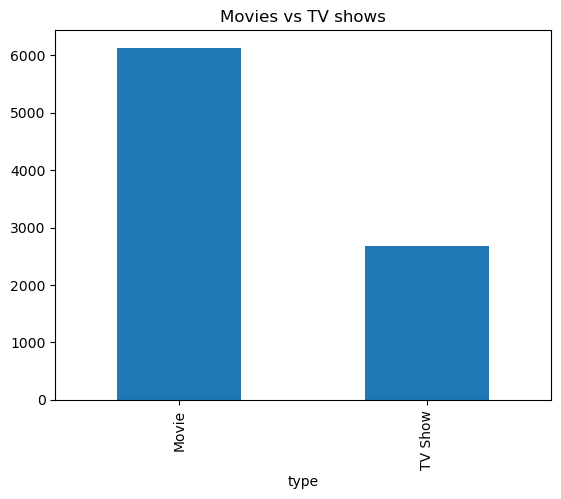

In [216]:
# the distibution of movies and tv shows:
data["type"].value_counts().plot(kind="bar", title="Movies vs TV shows")
plt.show()

**Insight:** Movies are more numerous than TV Shows in the Netflix dataset, showing that the platform's catalog is dominated by films.

## 2. Content Added Over Time

This section analyzes how Netflix content has grown over the years.

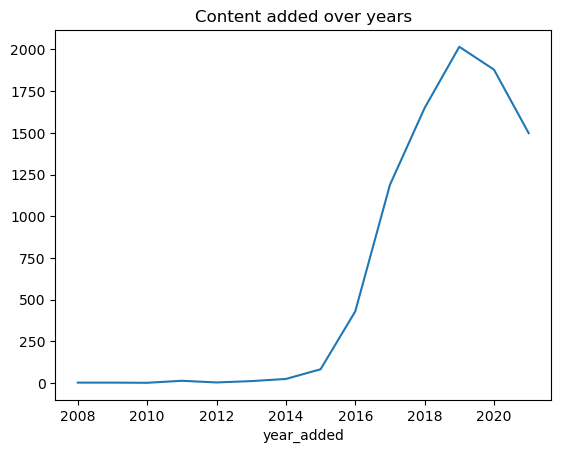

In [217]:
data["year_added"].value_counts().sort_index().plot(kind="line",title="Content added over years")
plt.show()

**Insight:** Netflix content increased significantly after 2015, showing rapid platform growth.

## 3. Top Countries

This section identifies the countries producing the most content.

In [218]:
#ignoring the unknown column values for the plot 
unknown_countries = (data["country"] == "Unknown").sum()
print(f"unknown country column values : {unknown_countries}" )

unknown country column values : 831


In [219]:
data["country"].value_counts().head(10)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

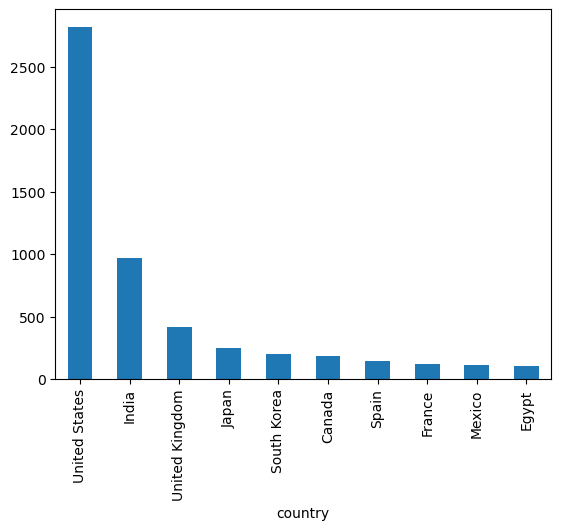

In [220]:
#top countries producing content neglicting the Unknown values of dataset:
data[data["country"] != "Unknown"]["country"].value_counts().head(10).plot(kind="bar")
plt.show()


**Insight:** The United States appears as the leading content producer, followed by a few other dominant countries.

## 4. Ratings Distribution

This section explores the distribution of content ratings.

In [221]:
data["rating"].value_counts().head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

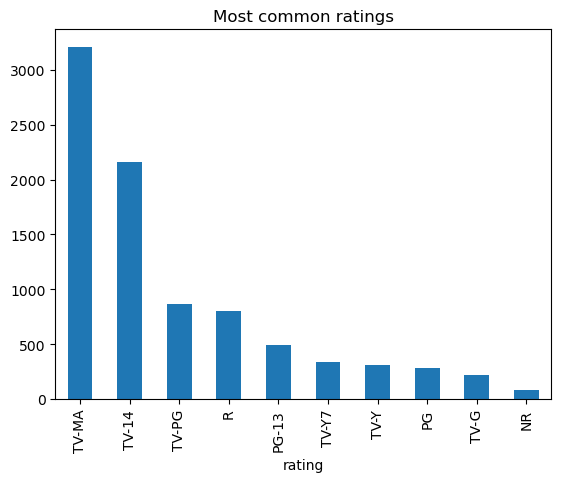

In [222]:
#most common ratings
#shows audience targeting
data["rating"].value_counts().head(10).plot(kind="bar", title="Most common ratings")
plt.show()

**Insight:** Ratings such as TV-MA and TV-14 dominate, suggesting that Netflix primarily targets mature and teenage audiences.

In [223]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


## 6. Movie Duration distribution

This section examines how movie durations are distributed.

<Axes: title={'center': 'Movie Duration Distribution'}, ylabel='Frequency'>

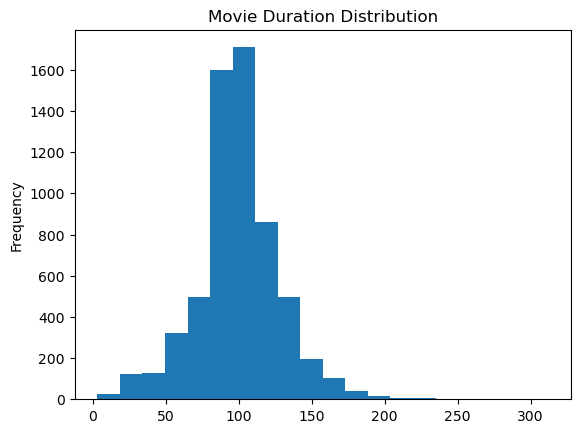

In [224]:
#showing how long movies 
movies["duration_int"].plot(kind="hist", bins=20, title="Movie Duration Distribution")

## Top Genres

This section analyzes the most common genres in the dataset.

In [225]:
genres = data["listed_in"].str.split(", ").explode()
genres.value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

<Axes: title={'center': 'Top Genres'}, xlabel='listed_in'>

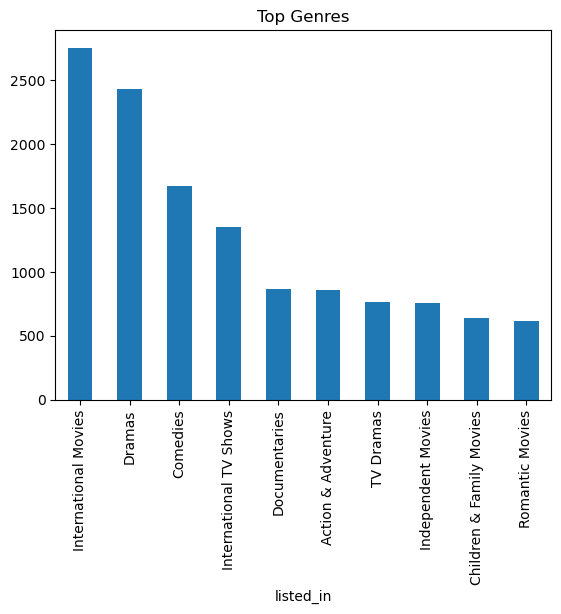

In [226]:
#top genres
genres.value_counts().head(10).plot(kind="bar", title="Top Genres")

**Insight:** Certain genres such as Drama and International Movies are highly represented in the dataset.

## 7. Top Actors

This section identifies the most frequently appearing actors.

In [227]:
#most frequent actors:
actors = data["cast"].str.split(", ").explode()
actors.value_counts().head(10)

cast
Unknown             825
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Naseeruddin Shah     32
Takahiro Sakurai     32
Rupa Bhimani         31
Akshay Kumar         30
Om Puri              30
Yuki Kaji            29
Name: count, dtype: int64

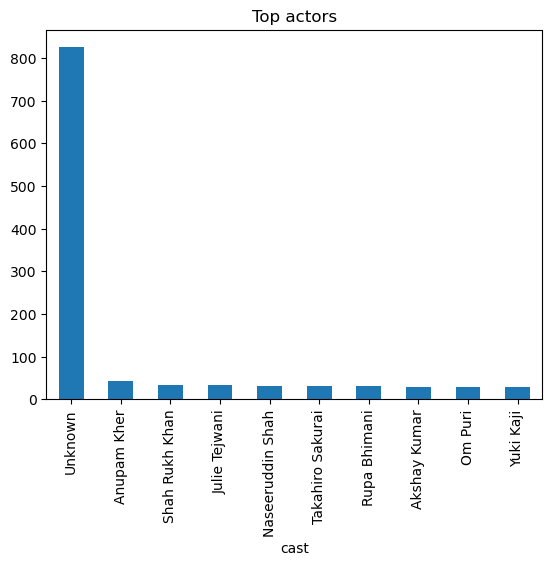

In [228]:
#top 10 actors 
actors.value_counts().head(10).plot(kind="bar",title="Top actors")
plt.show()

**Insight:** Some actors appear multiple times, indicating recurring collaborations or popular casting trends.

## Movies VS TV shows over Time

here we're exploring the production distribution of both movies, TV shows over the years. 

<Axes: xlabel='year_added'>

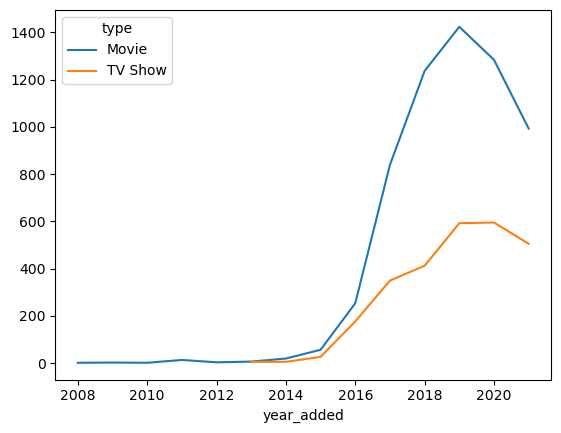

In [229]:
data.groupby(["year_added", "type"]).size().unstack().plot()

**insights:** we're observing that movies are much more than tvshows, which make sense looking to the production budget needed to make a tv shows vs a movie ,and the time it take to be finished.

In [230]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


## Conclusion

This project demonstrates a complete data analysis workflow, from data cleaning to insight generation. It highlights key patterns in Netflix content and provides a strong foundation for future data science projects.